In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel(r"C:\Users\udayk\OneDrive\Desktop\uday\HDI DATASET.xlsx") 

In [3]:
df.head()

,Country,HDI,Life_Expectancy,Expected_Schooling,Mean_Schooling,GNI,HDI_Category
0,Iceland,0.972,82.691,18.850590,13.908926,69116.93736,Very High
1,Norway,0.970,83.308,18.792850,13.117962,112710.02110,Very High
2,Switzerland,0.970,83.954,16.667530,13.949121,81948.90177,Very High
3,Denmark,0.962,81.933,18.704010,13.027321,76007.85669,Very High
4,Germany,0.959,81.378,17.309219,14.296372,64053.22124,Very High


In [4]:
df.tail()

,Country,HDI,Life_Expectancy,Expected_Schooling,Mean_Schooling,GNI,HDI_Category
188,Niger,0.419,61.183,8.308920,1.412289,1590.187960,Low
189,Chad,0.416,55.069,8.347590,2.334985,1748.000992,Low
190,Central African Republic,0.414,57.408,7.435768,3.989431,1099.860681,Low
191,Somalia,0.404,58.816,7.486165,1.900000,1474.738459,Low
192,South Sudan,0.388,57.617,5.634770,5.730000,688.347277,Low


In [5]:
df.describe()

,HDI,Life_Expectancy,Expected_Schooling,Mean_Schooling,GNI
count,193.000000,193.000000,193.000000,193.000000,193.000000
mean,0.740798,73.111523,13.584760,9.173126,24620.680478
std,0.151608,7.166191,3.074275,3.187013,25961.982601
min,0.388000,54.462000,5.634770,1.412289,688.347277
25%,0.622000,67.385000,11.504560,6.780046,5746.568969
50%,0.762000,73.490000,13.335777,9.933020,15866.542070
75%,0.862000,78.341000,15.888260,11.641718,36792.988740
max,0.972000,85.706000,20.845501,14.296372,166811.674100


In [6]:
df.isnull().sum()

Country                  0
       HDI               0
Life_Expectancy          0
Expected_Schooling       0
Mean_Schooling           0
                  GNI    0
HDI_Category             0
dtype: int64

In [7]:
df["HDI_Category"].value_counts()

HDI_Category
Very High    74
High         50
Medium       43
Low          26
Name: count, dtype: int64

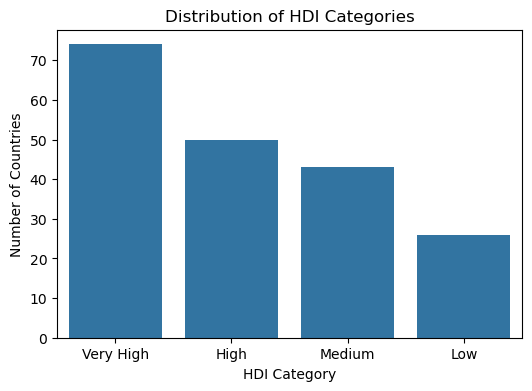

In [8]:
plt.figure(figsize=(6,4))

sns.countplot(x="HDI_Category", data=df)

plt.title("Distribution of HDI Categories")
plt.xlabel("HDI Category")
plt.ylabel("Number of Countries")

plt.show()

In [13]:
df.columns = df.columns.str.strip()

print(df.columns.tolist())

['Country', 'HDI', 'Life_Expectancy', 'Expected_Schooling', 'Mean_Schooling', 'GNI', 'HDI_Category']


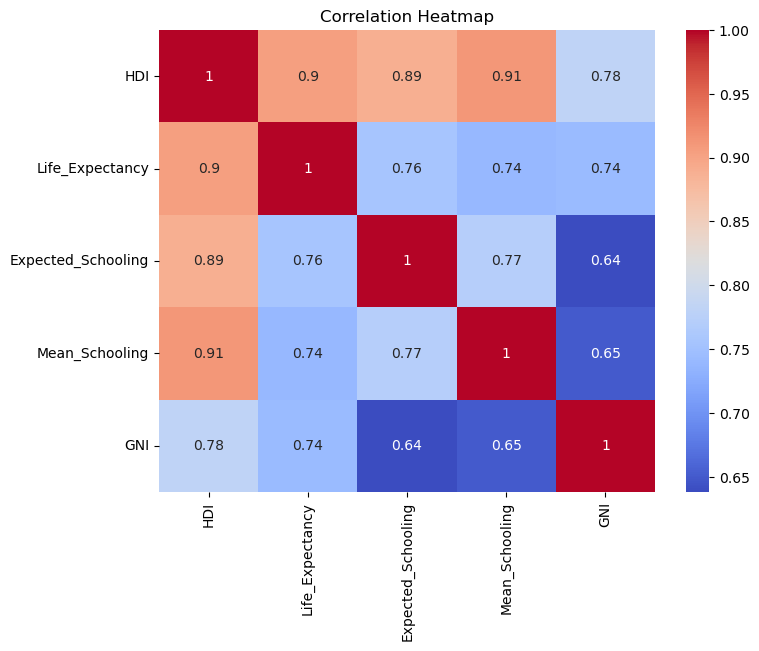

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    df[[
        "HDI",
        "Life_Expectancy",
        "Expected_Schooling",
        "Mean_Schooling",
        "GNI"
    ]].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

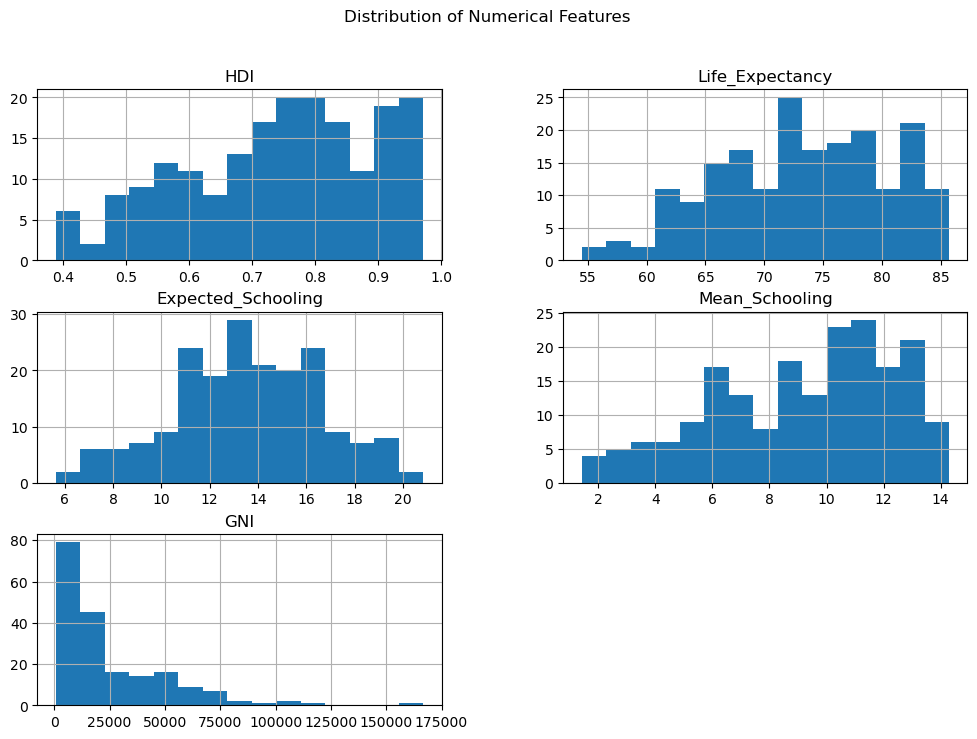

In [15]:
import matplotlib.pyplot as plt

df.hist(figsize=(12,8), bins=15)
plt.suptitle("Distribution of Numerical Features")
plt.show()

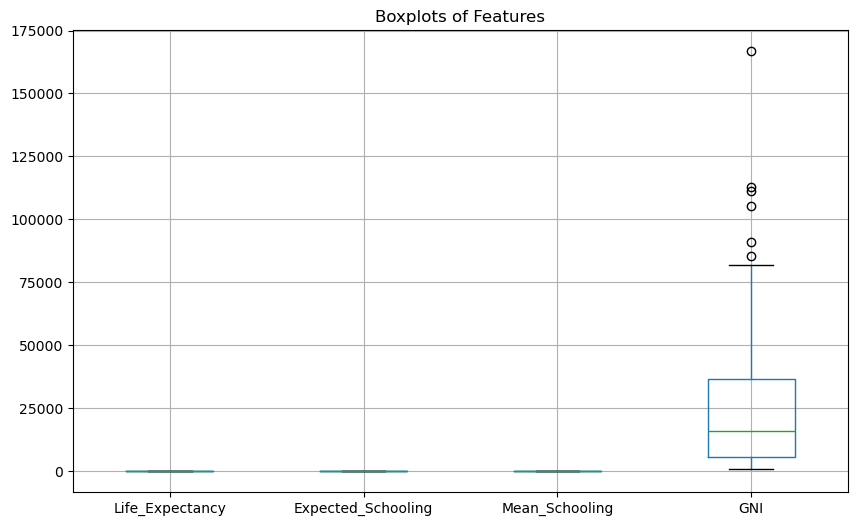

In [16]:
plt.figure(figsize=(10,6))

df[[
    "Life_Expectancy",
    "Expected_Schooling",
    "Mean_Schooling",
    "GNI"
]].boxplot()

plt.title("Boxplots of Features")
plt.show()

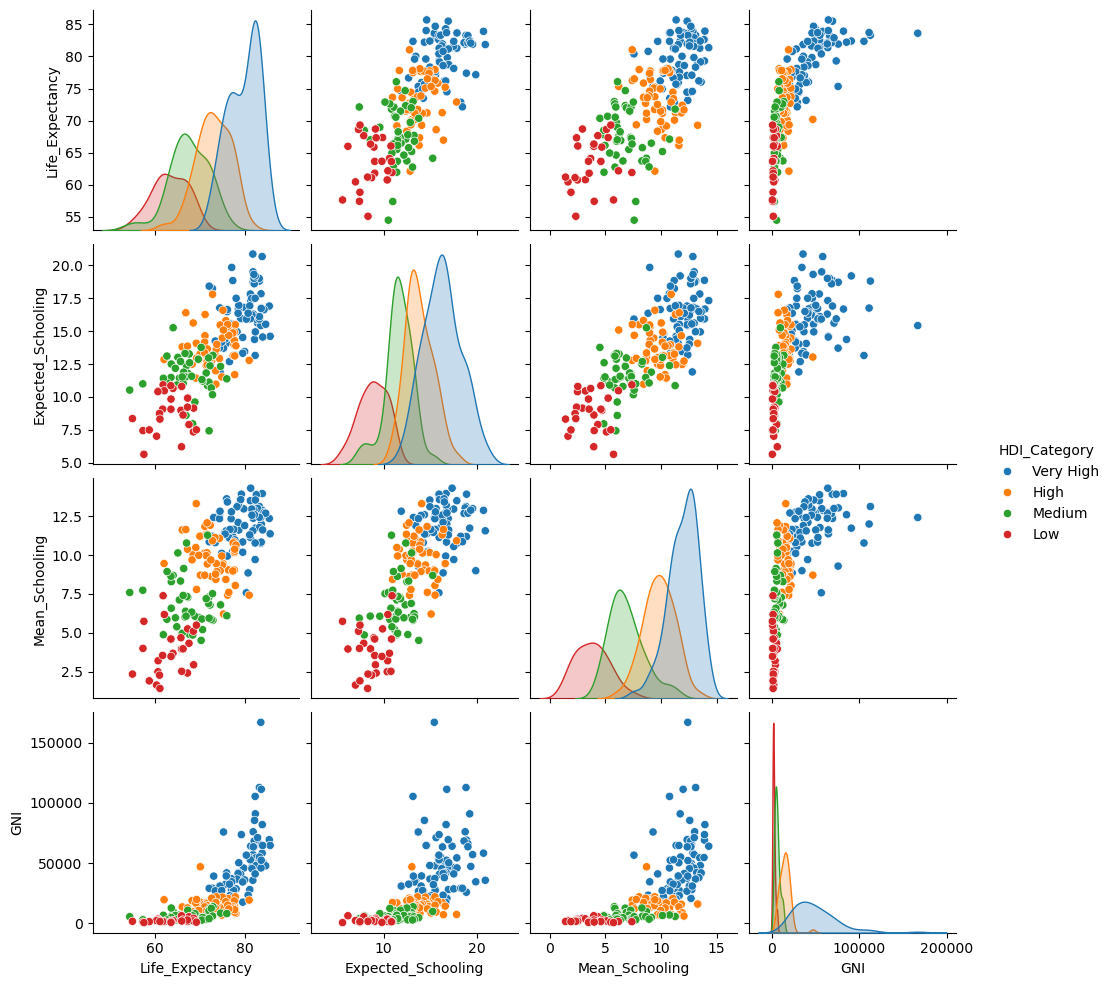

In [17]:
import seaborn as sns

sns.pairplot(
    df,
    vars=[
        "Life_Expectancy",
        "Expected_Schooling",
        "Mean_Schooling",
        "GNI"
    ],
    hue="HDI_Category"
)

plt.show()

In [18]:
print(df.corr(numeric_only=True)["HDI"].sort_values(ascending=False))

HDI                   1.000000
Mean_Schooling        0.911369
Life_Expectancy       0.904591
Expected_Schooling    0.888701
GNI                   0.781239
Name: HDI, dtype: float64


In [1]:
# ============================================
# PHASE 3 : DATA PREPARATION
# ============================================

# Import Libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Load Dataset
df = pd.read_excel(r"C:\Users\udayk\OneDrive\Desktop\uday\HDI DATASET.xlsx")

# Remove extra spaces from column names
df.columns = df.columns.str.strip()

# -------------------------------
# Features (Input)
# -------------------------------
X = df[[
    "Life_Expectancy",
    "Expected_Schooling",
    "Mean_Schooling",
    "GNI"
]]

# -------------------------------
# Target (Output)
# -------------------------------
y = df["HDI_Category"]

# -------------------------------
# Encode Target Labels
# -------------------------------
label_encoder = LabelEncoder()

y = label_encoder.fit_transform(y)

print("Encoded Classes:")
print(label_encoder.classes_)

# -------------------------------
# Split Dataset
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# -------------------------------
# Feature Scaling
# -------------------------------
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# -------------------------------
# Display Dataset Information
# -------------------------------
print("\nDataset Successfully Prepared!\n")

print("Training Features Shape :", X_train.shape)
print("Testing Features Shape  :", X_test.shape)

print("Training Labels Shape   :", y_train.shape)
print("Testing Labels Shape    :", y_test.shape)

print("\nFirst 5 Training Samples:")
print(X_train[:5])

print("\nFirst 5 Training Labels:")
print(y_train[:5])

Encoded Classes:
['High' 'Low' 'Medium' 'Very High']

Dataset Successfully Prepared!

Training Features Shape : (154, 4)
Testing Features Shape  : (39, 4)
Training Labels Shape   : (154,)
Testing Labels Shape    : (39,)

First 5 Training Samples:
[[-1.4549541  -0.1517891  -1.03930519 -0.81050873]
 [-0.45027777 -0.24469123  0.25844503 -0.52271303]
 [ 0.65735876  0.14023919  0.53045997 -0.32666829]
 [-0.83662638 -0.39339308  0.50758957 -0.65886579]
 [ 0.22314145  0.63907968 -0.05596926 -0.43860868]]

First 5 Training Labels:
[2 0 0 2 0]


In [2]:
# ============================================
# PHASE 4 : MODEL TRAINING
# ============================================

# Import Libraries
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score

# Dictionary of Models
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC()
}

print("="*50)
print("MODEL TRAINING RESULTS")
print("="*50)

results = {}

for name, model in models.items():

    # Train Model
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Accuracy
    accuracy = accuracy_score(y_test, y_pred)

    results[name] = accuracy

    print(f"{name} Accuracy : {accuracy*100:.2f}%")

print("="*50)

MODEL TRAINING RESULTS
Decision Tree Accuracy : 89.74%
Random Forest Accuracy : 97.44%
Logistic Regression Accuracy : 97.44%
KNN Accuracy : 92.31%
SVM Accuracy : 94.87%


Random Forest Evaluation
Accuracy : 97.44%

Classification Report

              precision    recall  f1-score   support

        High       1.00      0.90      0.95        10
         Low       1.00      1.00      1.00         5
      Medium       1.00      1.00      1.00         9
   Very High       0.94      1.00      0.97        15

    accuracy                           0.97        39
   macro avg       0.98      0.97      0.98        39
weighted avg       0.98      0.97      0.97        39



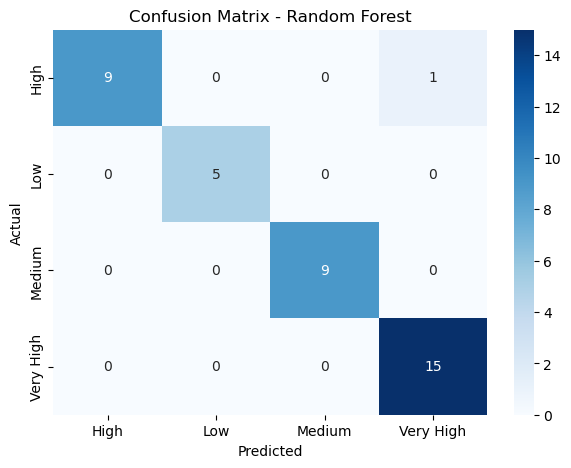

In [3]:
# ============================================
# PHASE 5 : MODEL EVALUATION
# ============================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score
)
import matplotlib.pyplot as plt
import seaborn as sns

# Train Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Predictions
y_pred = rf_model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("="*50)
print("Random Forest Evaluation")
print("="*50)

print(f"Accuracy : {accuracy*100:.2f}%")

print("\nClassification Report\n")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")

plt.show()

In [4]:
# ============================================
# PHASE 6 : SAVE THE MODEL
# ============================================

# Import Libraries
import joblib
import os

print("=" * 50)
print("SAVING TRAINED MODEL")
print("=" * 50)

# ------------------------------------
# Save Random Forest Model
# ------------------------------------
joblib.dump(rf_model, "hdi_model.pkl")

# ------------------------------------
# Save Standard Scaler
# ------------------------------------
joblib.dump(scaler, "scaler.pkl")

# ------------------------------------
# Save Label Encoder
# ------------------------------------
joblib.dump(label_encoder, "label_encoder.pkl")

# ------------------------------------
# Verify Saved Files
# ------------------------------------
files = [
    "hdi_model.pkl",
    "scaler.pkl",
    "label_encoder.pkl"
]

print("\nChecking Saved Files...\n")

for file in files:

    if os.path.exists(file):

        size = os.path.getsize(file) / 1024

        print(f"✅ {file}  ({size:.2f} KB)")

    else:

        print(f"❌ {file} was NOT created!")

print("\n" + "=" * 50)
print("MODEL SAVED SUCCESSFULLY")
print("=" * 50)

print("\nSaved Files:")
print("1. hdi_model.pkl")
print("2. scaler.pkl")
print("3. label_encoder.pkl")

print("\nYou can now use these files in Flask.")

SAVING TRAINED MODEL

Checking Saved Files...

✅ hdi_model.pkl  (321.54 KB)
✅ scaler.pkl  (1.05 KB)
✅ label_encoder.pkl  (0.56 KB)

MODEL SAVED SUCCESSFULLY

Saved Files:
1. hdi_model.pkl
2. scaler.pkl
3. label_encoder.pkl

You can now use these files in Flask.


In [5]:
import joblib

model = joblib.load("hdi_model.pkl")
scaler = joblib.load("scaler.pkl")
label_encoder = joblib.load("label_encoder.pkl")